# BASE DE DADOS REITS:

### 1. Importando bibliotecas:

In [1]:
import requests
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from edgar_functions import *
import os
from bs4 import BeautifulSoup
import logging  
import calendar

/Users/patrickdacasalmeida/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### 2. Definindo variáveis como ativo utilizado, chave API e header:

In [2]:
# Exemplo de uso: coletando todas as demonstrações de PLD
symbol = 'PLD'

# Substitua pela sua chave da API Alpha Vantage
api_key = 'P5LK4NU39VFWSMWQ'

headers = {"User-Agent": "patrickca@al.insper.edu.br"}    # change to your own headers file or add variable in code

caminho_base = 'Base_REITs.xlsx'

### 3.1 Exemplo de geração de base de dados utilizando o AlphaVantage:

In [ ]:
#API

financials = get_all_financials(symbol, api_key)

# Exibindo cada demonstração coletada
for report_name, df in financials.items():
    print(f"\n{report_name}:\n", df.head())

reit_metrics_df = calculate_reit_metrics_API(symbol, api_key)

# Exibindo o DataFrame de métricas calculadas
print(reit_metrics_df)

# Calculando o crescimento percentual da Receita Total
result_df = metric_growth(reit_metrics_df)

# Mostra o DataFrame resultante
print(result_df)

### 3.2 Exemplo de geração de base de dados utilizando a API do EDGAR SEC:

In [3]:
all_statements = process_all_statements_for_ticker(symbol, headers=headers)

df_balance_sheet = create_financial_statement_data_frame(all_statements,'balance_sheet').set_index('index')#, inplace=True)
df_income_statement = create_financial_statement_data_frame(all_statements,'income_statement').set_index('index')#, inplace=True)
df_cash_flow_statement = create_financial_statement_data_frame(all_statements,'cash_flow_statement').set_index('index')#, inplace=True)

In [ ]:
df_income_statement

In [3]:
metrics = calculate_reit_metrics_EDGAR(symbol, headers, caminho_base) #, df_balance_sheet, df_income_statement, df_cash_flow_statement
metrics

,REIT,Setor,Data Fiscal,Período,Preço do REIT,Market Cap,Shares Outstanding,Receita Total,Fluxo de Caixa Operacional,Margem Bruta,...,NAV,NAV (Por Ação),NOI,Cap Rate,Dividendos Anuais (Por Ação),Dividend Yield,Payout Ratio,Dívida Total,Debt-to-EBITDA,Cobertura de Juros
0,PLD,Industrial,2023-12-31,2023,130.22,"120,370,003,870.70","924,351,000","8,023,469,000","5,373,058,000",0.46,...,"57,823,720,000",62.56,"5,198,444,000",0.06,3.49,"24,793,132.63",0.66,"29,000,501,000",4.53,8.11
1,PLD,Industrial,2022-12-31,2022,107.11,"84,150,874,403.57","785,675,000","5,973,692,000","4,126,430,000",0.58,...,"57,863,093,000",73.65,"3,728,369,000",0.04,3.18,"23,291,992.00",0.51,"23,875,961,000",4.25,12.06
2,PLD,Industrial,2021-12-31,2021,155.96,"115,313,822,481.08","739,363,000","4,759,440,000","2,996,042,000",0.67,...,"37,742,210,000",51.05,"3,127,374,000",0.05,2.53,"12,008,310.00",0.44,"17,715,054,000",3.57,11.75
3,PLD,Industrial,2020-12-31,2020,90.50,"65,915,348,588.80","728,323,000","4,438,735,000","2,937,005,000",0.48,...,"36,324,580,000",49.87,NaN,NaN,2.37,"19,037,941.00",0.63,"16,849,076,000",5.22,NaN
4,PLD,Industrial,2019-12-31,2019,78.88,"49,737,796,116.64","630,580,000","3,330,621,000","2,264,034,000",0.56,...,"26,071,784,000",41.35,NaN,NaN,2.13,"17,060,391.67",0.54,"11,905,877,000",4.14,NaN
5,PLD,Industrial,2018-12-31,2018,50.61,"28,711,773,428.95","567,367,000","2,804,449,000","1,803,559,000",0.30,...,"25,800,888,000",45.47,NaN,NaN,1.98,"22,198,606.65",0.47,"11,089,815,000",4.01,NaN
6,PLD,Industrial,2017-12-31,2017,53.98,"28,629,959,866.33","530,400,000",NaN,NaN,NaN,...,"18,705,741,000",35.27,NaN,NaN,1.78,"17,467,913.89",0.42,"9,412,631,000",3.42,NaN


In [4]:
metrics_growth = metric_growth(metrics)
metrics_growth

,REIT,Setor,Data Fiscal,Período,Crescimento (%) Setor,Crescimento (%) Preço do REIT,Crescimento (%) Market Cap,Crescimento (%) Shares Outstanding,Crescimento (%) Receita Total,Crescimento (%) Fluxo de Caixa Operacional,...,Crescimento (%) NAV,Crescimento (%) NAV (Por Ação),Crescimento (%) NOI,Crescimento (%) Cap Rate,Crescimento (%) Dividendos Anuais (Por Ação),Crescimento (%) Dividend Yield,Crescimento (%) Payout Ratio,Crescimento (%) Dívida Total,Crescimento (%) Debt-to-EBITDA,Crescimento (%) Cobertura de Juros
0,PLD,Industrial,2023-12-31,2023,None,21.58,43.04,17.65,34.31,30.21,...,-0.07,-15.06,39.43,31.75,10.00,6.44,28.51,21.46,6.76,-32.81
1,PLD,Industrial,2022-12-31,2022,None,-31.33,-27.02,6.26,25.51,37.73,...,53.31,44.27,19.22,-20.67,25.35,93.97,16.32,34.78,18.86,2.70
2,PLD,Industrial,2021-12-31,2021,None,72.33,74.94,1.52,7.23,2.01,...,3.90,2.35,NaN,NaN,7.08,-36.92,-30.22,5.14,-31.55,NaN
3,PLD,Industrial,2020-12-31,2020,None,14.74,32.53,15.50,33.27,29.72,...,39.33,20.63,NaN,NaN,10.86,11.59,16.01,41.52,26.19,NaN
4,PLD,Industrial,2019-12-31,2019,None,55.87,73.23,11.14,18.76,25.53,...,1.05,-9.08,NaN,NaN,7.78,-23.15,14.68,7.36,3.04,NaN
5,PLD,Industrial,2018-12-31,2018,None,-6.25,0.29,6.97,NaN,NaN,...,37.93,28.94,NaN,NaN,11.38,27.08,13.58,17.82,17.35,NaN
6,PLD,Industrial,2017-12-31,2017,None,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4 Exemplo de criação de gráficos para visualização dos dados:

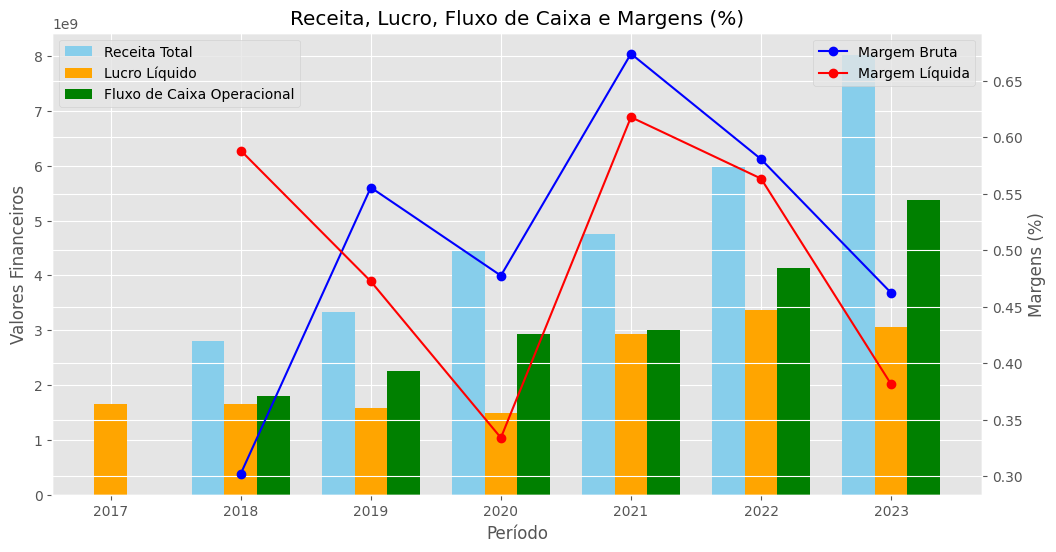

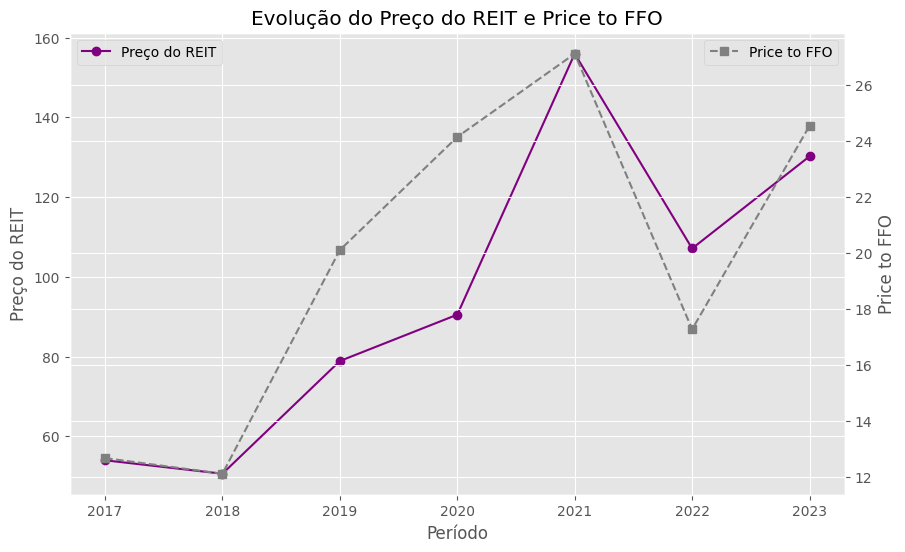

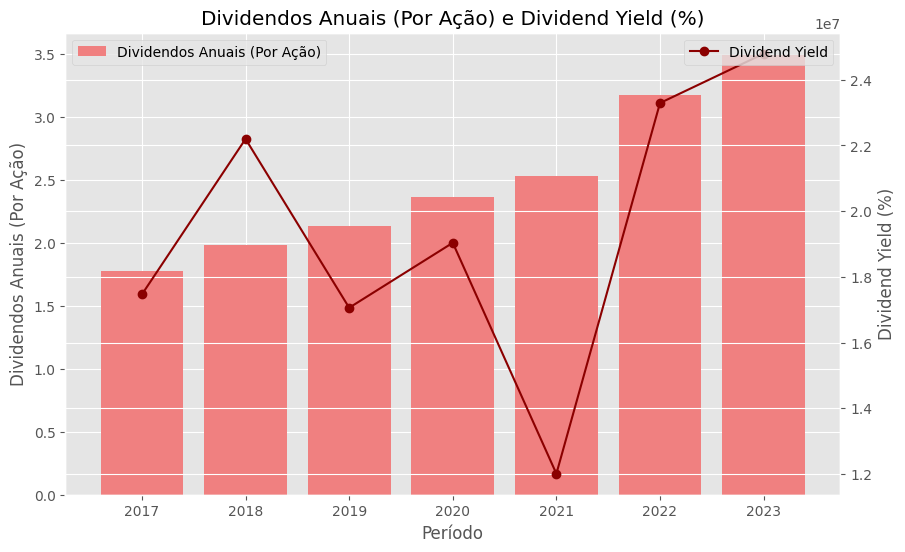

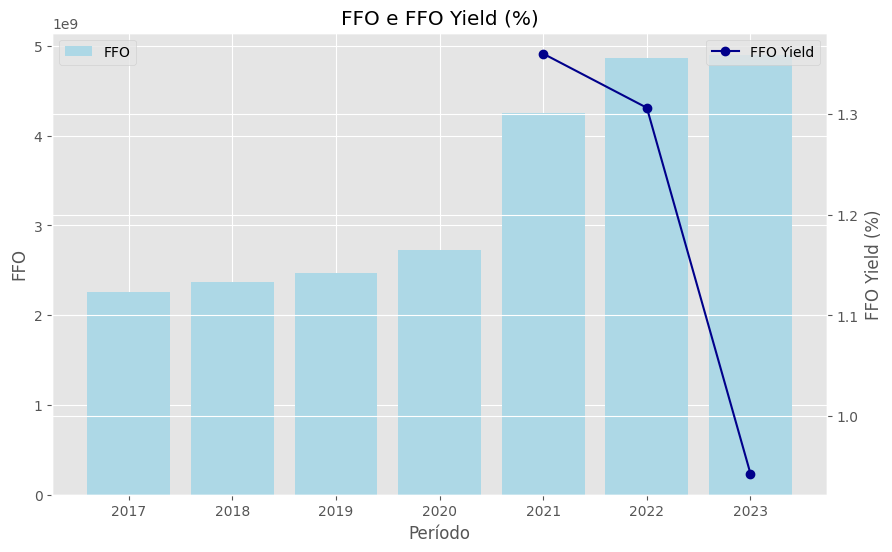

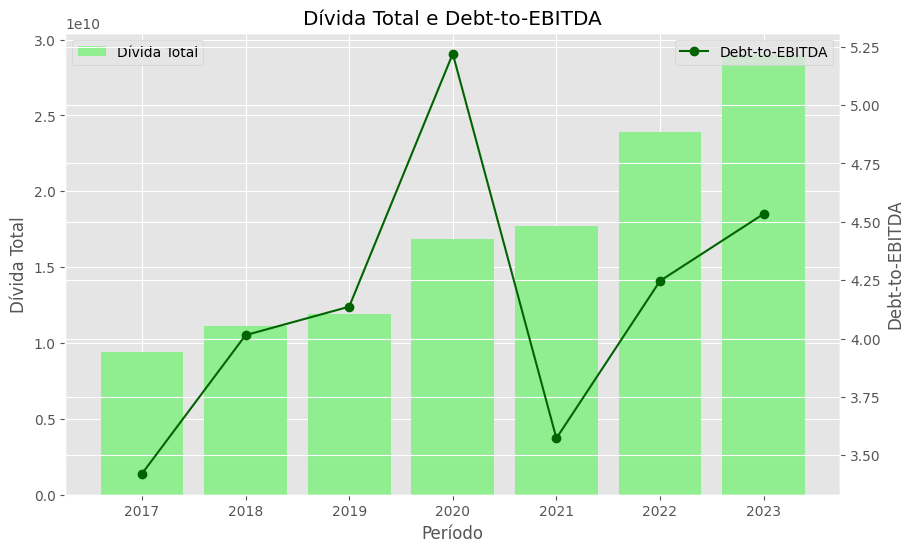

In [5]:
# Exemplo de uso da função com o DataFrame `metrics`
generate_graphs(metrics)

In [3]:
base_reits = pd.read_excel(caminho_base)
base_reits

,REIT Name,Ticker,Sector
0,Camden Property Trust,CPT,Apartment
1,BRT Apartments,BRT,Apartment
2,Equity Residential,EQR,Apartment
3,UDR,UDR,Apartment
4,Elme Communities,ELME,Apartment
...,...,...,...
74,Park Hotels,PK,Lodging
75,American Tower Corp,AMT,Tower
76,Crown Castle,CCI,Tower
77,Gaming & Leisure Properties,GLPI,Gaming


In [4]:
lista_reits = base_reits['Ticker'].to_list()
lista_reits

['CPT',
 'BRT',
 'EQR',
 'UDR',
 'ELME',
 'AVB',
 'MAA',
 'AIRC',
 'ESS',
 'UMH',
 'MHC',
 'AMH',
 'INVH',
 'PLD',
 'FR',
 'TRNO',
 'EGP',
 'REXR',
 'LXP',
 'STAG',
 'DLR',
 'EQIX',
 'PSA',
 'CUBE',
 'EXR',
 'NSA',
 'WELL',
 'VTR',
 'HR',
 'OHI',
 'SBRA',
 'DOC',
 'MPW',
 'NNN',
 'CTO',
 'PSTL',
 'BNL',
 'O',
 'WPC',
 'ADC',
 'EPRT',
 'BXP',
 'CUZ',
 'HIW',
 'KRC',
 'VNO',
 'SLG',
 'BDN',
 'DEI',
 'PDM',
 'HPP',
 'AAT',
 'ESRT',
 'PGRE',
 'SITC',
 'KIM',
 'REG',
 'WSR',
 'ROIC',
 'AKR',
 'BRX',
 'UE',
 'KRG',
 'PECO',
 'FRT',
 'IVT',
 'SKT',
 'SPG',
 'HST',
 'SHO',
 'DRH',
 'PEB',
 'RLJ',
 'APLE',
 'PK',
 'AMT',
 'CCI',
 'GLPI',
 'VICI']

In [20]:
df = cik_matching_ticker('UDR', headers=headers)
print(df)
accn = '000095017024015907'

0000074208


In [21]:
accn_df = get_filtered_filings('UDR', ten_k=True, just_accession_numbers=False, headers=headers)
accn_df

,accessionNumber,filingDate,reportDate,acceptanceDateTime,act,form,fileNumber,filmNumber,items,core_type,size,isXBRL,isInlineXBRL,primaryDocument,primaryDocDescription
40,0000074208-24-000011,2024-02-20,2023-12-31,2024-02-20T16:11:33.000Z,34,10-K,001-10524,24653397,,XBRL,35957831,1,1,udr-20231231x10k.htm,10-K
104,0000074208-23-000007,2023-02-13,2022-12-31,2023-02-13T14:59:15.000Z,34,10-K,001-10524,23617452,,XBRL,36837870,1,1,udr-20221231x10k.htm,10-K
164,0000074208-22-000010,2022-02-15,2021-12-31,2022-02-15T15:16:13.000Z,34,10-K,001-10524,22638813,,XBRL,35128665,1,1,udr-20211231x10k.htm,10-K
252,0000074208-21-000025,2021-02-18,2020-12-31,2021-02-18T15:23:09.000Z,34,10-K,001-10524,21649276,,XBRL,55234989,1,1,udr-20201231x10k.htm,10-K
330,0000074208-20-000031,2020-02-18,2019-12-31,2020-02-18T16:58:55.000Z,34,10-K,001-10524,20626133,,XBRL,53437616,1,1,udr-20191231x10k.htm,10-K
418,0000074208-19-000028,2019-02-19,2018-12-31,2019-02-19T15:01:03.000Z,34,10-K,001-10524,19614653,,10-K,62851702,1,0,c208-20181231x10k.htm,10-K
513,0000074208-18-000024,2018-02-20,2017-12-31,2018-02-20T15:11:54.000Z,34,10-K,001-10524,18624305,,10-K,61131573,1,0,c208-20171231x10k.htm,10-K
591,0000074208-17-000030,2017-02-21,2016-12-31,2017-02-21T16:27:52.000Z,34,10-K,001-10524,17625390,,10-K,46251613,1,0,a201610-k.htm,10-K
676,0000074208-16-000140,2016-02-23,2015-12-31,2016-02-23T16:32:09.000Z,34,10-K,001-10524,161448737,,10-K,49342442,1,0,a201510-k.htm,10-K
796,0000074208-15-000013,2015-02-24,2014-12-31,2015-02-24T16:53:23.000Z,34,10-K,001-10524,15644210,,10-K,73350773,1,0,udr-20141231x10k.htm,10-K


In [7]:
soup = get_statement_soup('NNN', accn, 'income_statement', headers=headers,statement_keys_map=statement_keys_map)

In [8]:
statement_file_name_dict = get_statement_file_names_in_filing_summary(
        'NNN', accn, headers)

statement_file_name_dict

{'consolidated balance sheets': 'R2.htm',
 'consolidated balance sheets (parenthetical)': 'R3.htm',
 'consolidated statements of income and comprehensive income': 'R4.htm',
 'consolidated statements of equity': 'R5.htm',
 'consolidated statements of equity (parenthetical)': 'R6.htm',
 'consolidated statements of cash flows': 'R7.htm',
 'consolidated statements of cash flows (parenthetical)': 'R8.htm'}

In [31]:
statement_name = 'income_statement'

base_link = f"https://www.sec.gov/Archives/edgar/data/{df}/{accn}"

statement_link = None
for possible_key in statement_keys_map.get(statement_name.lower(), []):
        file_name = statement_file_name_dict.get(possible_key.lower())
        if file_name:
            statement_link = f"{base_link}/{file_name}"
            break

statement_link

'https://www.sec.gov/Archives/edgar/data/0000906345/000095017024014539/R4.htm'

In [22]:
teste = process_all_statements_for_ticker('UDR', headers=headers)


ERROR:root:Failed to get statement soup: Could not find statement file name for income_statement for accession number: 000007420817000030
ERROR:root:Failed to get statement soup: Could not find statement file name for income_statement for accession number: 000007420816000140
ERROR:root:Failed to get statement soup: Could not find statement file name for income_statement for accession number: 000007420815000013
ERROR:root:Failed to get statement soup: Could not find statement file name for income_statement for accession number: 000007420814000003
ERROR:root:Failed to get statement soup: Could not find statement file name for income_statement for accession number: 000007420813000007


In [10]:
# Lista para armazenar os DataFrames gerados em cada iteração
dfs = []

# Loop para calcular as métricas e armazenar cada DataFrame na lista
for i in range(0, 2):
    # Substitua 'symbol' com o ticker apropriado para cada iteração, se necessário
    df = calculate_reit_metrics_EDGAR(lista_reits[i], headers, caminho_base)
    
    # Adiciona o DataFrame gerado à lista
    dfs.append(df)

# Concatena todos os DataFrames da lista em um único DataFrame
final_df = pd.concat(dfs, ignore_index=True)

# Exibe o DataFrame final
print(final_df)


ERROR:root:Failed to get statement soup: Could not find statement file name for income_statement for accession number: 000119312512067347
ERROR:root:Failed to get statement soup: Could not find statement file name for balance_sheet for accession number: 000095012310017017
ERROR:root:Failed to get statement soup: Could not find statement file name for income_statement for accession number: 000095012310017017
ERROR:root:Failed to get statement soup: Could not find statement file name for cash_flow_statement for accession number: 000095012310017017


KeyError: 'income_statement'